In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import *

import os


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\X280\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\X280\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\X280\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.

AttributeError: _ARRAY_API not found

In [2]:
train_cat = len(os.listdir("dataset/training_set/training_set/cats"))
train_dog = len(os.listdir("dataset/training_set/training_set/dogs"))

print("Cats:", train_cat)
print("Dogs:", train_dog)

Cats: 4001
Dogs: 4006


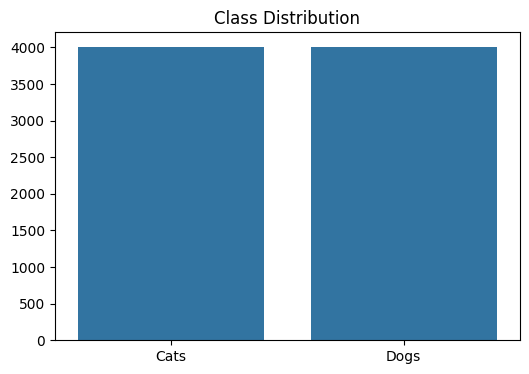

In [3]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=["Cats","Dogs"],
    y=[train_cat,train_dog]
)

plt.title("Class Distribution")

plt.show()

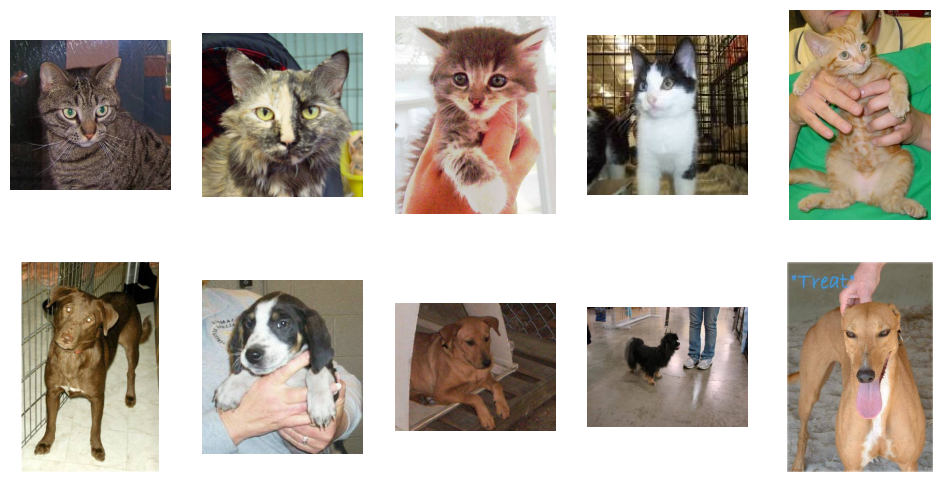

In [4]:
fig, axes = plt.subplots(2,5, figsize=(12,6))

cat_folder = "dataset/training_set/training_set/cats"
dog_folder = "dataset/training_set/training_set/dogs"

for i,img_name in enumerate(os.listdir(cat_folder)[:5]):

    img = plt.imread(
        os.path.join(cat_folder,img_name)
    )

    axes[0,i].imshow(img)
    axes[0,i].axis("off")

for i,img_name in enumerate(os.listdir(dog_folder)[:5]):

    img = plt.imread(
        os.path.join(dog_folder,img_name)
    )

    axes[1,i].imshow(img)
    axes[1,i].axis("off")

plt.show()

In [5]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

In [6]:
train_data = train_datagen.flow_from_directory(

    "dataset/training_set/training_set",

    target_size=(128,128),

    batch_size=32,

    class_mode="binary",

    subset="training"
)

Found 6404 images belonging to 2 classes.


In [7]:
val_data = train_datagen.flow_from_directory(

    "dataset/training_set/training_set",

    target_size=(128,128),

    batch_size=32,

    class_mode="binary",

    subset="validation"
)

Found 1601 images belonging to 2 classes.


In [8]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_data = test_datagen.flow_from_directory(

    "dataset/test_set/test_set",

    target_size=(128,128),

    batch_size=32,

    class_mode="binary",

    shuffle=False
)

Found 2023 images belonging to 2 classes.


In [9]:
fnn = Sequential([

    Flatten(input_shape=(128,128,3)),

    Dense(512,activation="relu"),

    Dense(256,activation="relu"),

    Dense(1,activation="sigmoid")
])

fnn.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

c:\Users\X280\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
history_fnn = fnn.fit(

    train_data,

    validation_data=val_data,

    epochs=10
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 121s 595ms/step - accuracy: 0.5206 - loss: 1.9389 - val_accuracy: 0.5597 - val_loss: 0.6872
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 115s 569ms/step - accuracy: 0.5579 - loss: 0.7220 - val_accuracy: 0.5384 - val_loss: 0.7275
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 129s 643ms/step - accuracy: 0.5414 - loss: 0.7119 - val_accuracy: 0.5628 - val_loss: 0.6836
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 120s 594ms/step - accuracy: 0.5520 - loss: 0.6965 - val_accuracy: 0.5490 - val_loss: 0.6815
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 105s 520ms/step - accuracy: 0.5547 - loss: 0.6888 - val_accuracy: 0.5028 - val_loss: 0.6924
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 95s 473ms/step - accuracy: 0.5225 - loss: 0.6898 - val_accuracy: 0.5434 - val_loss: 0.6905
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 104s 518ms/step - accuracy: 0.5525 - loss: 0.6849 - val_accuracy: 0.5472 - val_loss: 0.6850
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 176s 685ms/step - accuracy: 0.5186 - 

In [11]:
cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\X280\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']
)

In [13]:
history_cnn = cnn.fit(

train_data,

validation_data=val_data,

epochs=10
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 127s 616ms/step - accuracy: 0.5412 - loss: 0.7450 - val_accuracy: 0.5871 - val_loss: 0.6800
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 117s 582ms/step - accuracy: 0.6027 - loss: 0.6655 - val_accuracy: 0.6427 - val_loss: 0.6511
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 121s 600ms/step - accuracy: 0.6597 - loss: 0.6335 - val_accuracy: 0.6833 - val_loss: 0.6246
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 125s 623ms/step - accuracy: 0.6863 - loss: 0.5965 - val_accuracy: 0.7027 - val_loss: 0.5765
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 117s 580ms/step - accuracy: 0.7203 - loss: 0.5525 - val_accuracy: 0.6933 - val_loss: 0.5778
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 101s 503ms/step - accuracy: 0.7256 - loss: 0.5367 - val_accuracy: 0.7339 - val_loss: 0.5362
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 88s 440ms/step - accuracy: 0.7447 - loss: 0.5086 - val_accuracy: 0.7458 - val_loss: 0.5044
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 93s 464ms/step - accuracy: 0.7601 - l

In [14]:
deep_cnn = Sequential([

Conv2D(
32,
(3,3),
activation='relu',
input_shape=(128,128,3)
),

BatchNormalization(),

MaxPooling2D(),

Conv2D(
64,
(3,3),
activation='relu'
),

BatchNormalization(),

MaxPooling2D(),

Conv2D(
128,
(3,3),
activation='relu'
),

BatchNormalization(),

MaxPooling2D(),

Dropout(0.3),

Flatten(),

Dense(
256,
activation='relu'
),

Dropout(0.5),

Dense(
1,
activation='sigmoid'
)

])

In [15]:
deep_cnn.compile(

optimizer='adam',

loss='binary_crossentropy',

metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    patience=2,

    factor=0.5
)

In [17]:
history_deep = deep_cnn.fit(

train_data,

validation_data=val_data,

epochs=15,

callbacks=[
    early_stop,
    reduce_lr
]
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 162s 787ms/step - accuracy: 0.5996 - loss: 1.1683 - val_accuracy: 0.4997 - val_loss: 1.1001 - learning_rate: 0.0010
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 165s 817ms/step - accuracy: 0.6488 - loss: 0.6545 - val_accuracy: 0.5440 - val_loss: 1.0284 - learning_rate: 0.0010
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 160s 795ms/step - accuracy: 0.6854 - loss: 0.5889 - val_accuracy: 0.5765 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 155s 770ms/step - accuracy: 0.7069 - loss: 0.5730 - val_accuracy: 0.6821 - val_loss: 0.6025 - learning_rate: 0.0010
Epoch 5/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 156s 773ms/step - accuracy: 0.7303 - loss: 0.5390 - val_accuracy: 0.7164 - val_loss: 0.5481 - learning_rate: 0.0010
Epoch 6/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 161s 801ms/step - accuracy: 0.7491 - loss: 0.5121 - val_accuracy: 0.7339 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 7/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 192s 953ms/step - accura

In [18]:
pred = deep_cnn.predict(test_data)

pred = (pred > 0.5).astype(int)

y_true = test_data.classes

64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 536ms/step


In [19]:
acc = accuracy_score(y_true,pred)

precision = precision_score(y_true,pred)

recall = recall_score(y_true,pred)

f1 = f1_score(y_true,pred)

auc = roc_auc_score(y_true,pred)

print(acc)
print(precision)
print(recall)
print(f1)
print(auc)

0.8433020266930301
0.816196542311192
0.8863636363636364
0.8498342018000947
0.8432807301501664


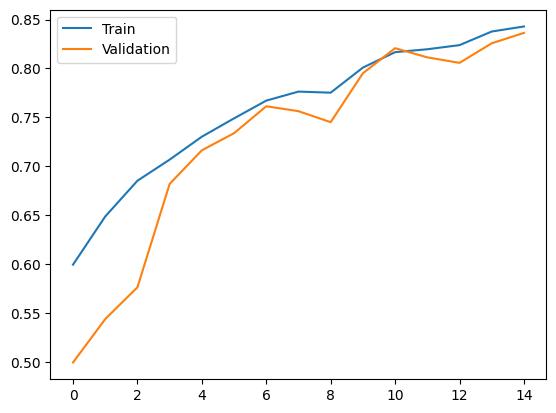

In [20]:
plt.plot(history_deep.history['accuracy'])

plt.plot(history_deep.history['val_accuracy'])

plt.legend([
    'Train',
    'Validation'
])

plt.show()

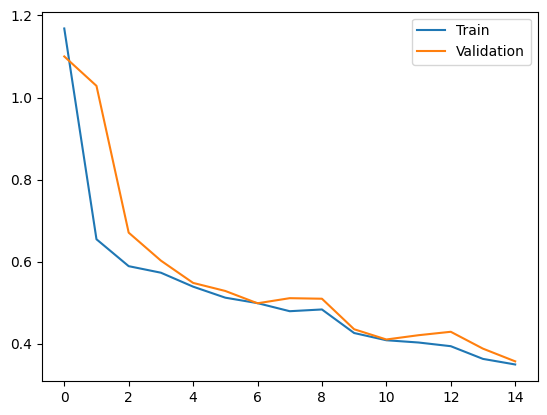

In [21]:
plt.plot(history_deep.history['loss'])

plt.plot(history_deep.history['val_loss'])

plt.legend([
    'Train',
    'Validation'
])

plt.show()

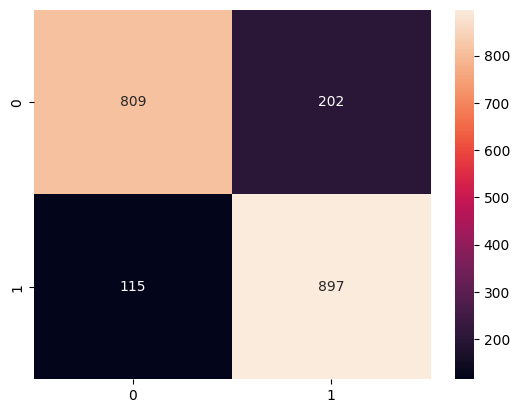

In [22]:
cm = confusion_matrix(
    y_true,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [23]:
deep_cnn.save(
    "best_model.keras"
)

In [24]:
model = load_model(
    "best_model.keras"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step


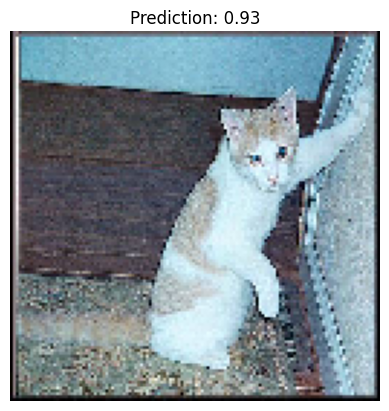

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


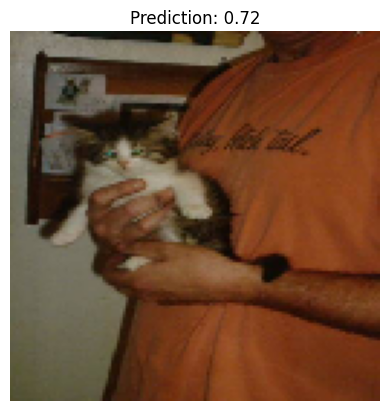

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


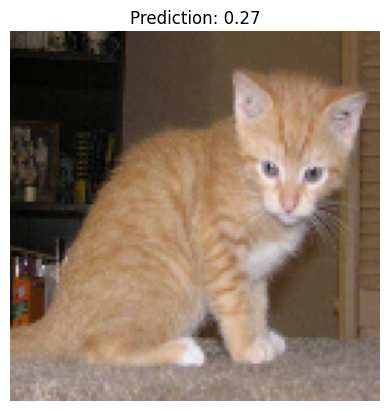

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


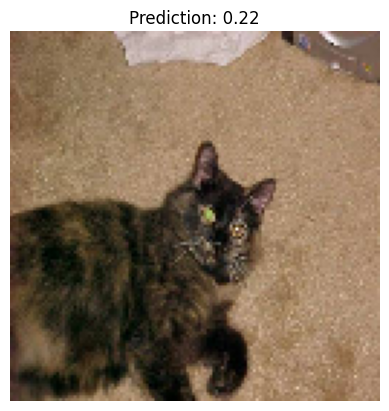

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


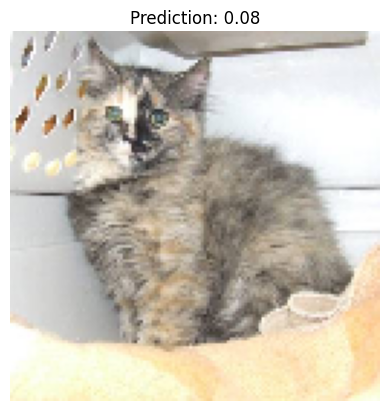

In [25]:
sample_files = test_data.filepaths[:5]

for img_path in sample_files:

    img = tf.keras.utils.load_img(
        img_path,
        target_size=(128,128)
    )

    arr = tf.keras.utils.img_to_array(img)

    arr = arr / 255.0

    arr = np.expand_dims(
        arr,
        axis=0
    )

    prediction = model.predict(arr)

    plt.imshow(img)

    plt.title(
        f"Prediction: {prediction[0][0]:.2f}"
    )

    plt.axis("off")

    plt.show()